# 🌟 Assignment 2. Operation "AI GeoGuessr"

### Deadline: Friday, October 24, 2025, 11:59:00 PM CET (GMT +2)

## 🎯 Mission Overview

The operation consists of two independent missions. Similar to the previous operation, students are required to solve the tasks by achieving the required score and answering the follow-up questions.

## 🧪 Neural Networks and Unsupervised Learning

1. **Mission 2.1 (Supervised Learning)**: 
   - Solve a supervised learning problem using a multilayer perceptron (MLP).

2. **Mission 2.2 (Unsupervised Learning)**:
   - Given an unlabeled dataset, your task is to cluster similar data points and achieve 100% clustering accuracy. You will not have access to the true labels, but you can verify your cluster assignments using the Kaggle competition provided.

## 📝 Delivery Format (Blackboard)

Please submit **two files**:
1. The completed Jupyter notebook.
2. The solution for the second dataset as a CSV file with two `int` columns: `['ID', 'cluster']`.

## Kaggle details
- Invitation link: https://www.kaggle.com/t/dfb72837bdb346449768b8f6ce50b6dc
- Kaggle is a popular platform for data science competitions.
- It allows us to create a Private competition where you can submit your solutions and verify whether you are thinking in the right direction.
- The results of the competition is visible only to the competition participants. 
- We will not grade the submissions on Kaggle, we set it up to let you check your clustering.
- You still have to deliver the `.csv` file of the solution and the complete `.ipynb` notebook with discussions and solution code.  

> Good luck, comrade!

In [53]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 🧠 Mission 2.1: Decoding SkyNet's Neural Encryption **(using Neural Networks)**

### 🌐 The Discovery
The dataset consists of the same "Synapse Cipher" data from Assignment 1.

### 🎯 Your Mission
1. Implement a multilayer perceptron (MLP) using one of the following frameworks: Keras, PyTorch, or TensorFlow.
2. Solve the non-linear problem without manual feature engineering.
3. Predict SkyNet's binary decisions (0 or 1) based on paired signals.
4. Improve performance by using techniques such as learning rate scheduling, selecting a good optimizer, and fine-tuning hyperparameters.

> Note: There are no restrictions on the tricks you can use — Have fun :) 

### 📊 Formal Requirements
1. **Implementation**:
   - Develop a Neural Network using predefined functions/layers.
   - Use one of the popular frameworks: Keras, PyTorch, or TensorFlow.
   - Implement a manual learning rate scheduler with warmup and cosine decay.

2. **Performance**: Achieve at least **0.92** accuracy on the test set.

3. **Discussion**:
   - How can you make sure the results are reproduable?
   - Visualize the network's architecture and decision boundary.
   - Which optimizer did you choose? Discuss the differences between SGD and Adam.
   - Plot the learning rate curve. Did the learning rate scheduling improve performance? Why or why not?
   - Conduct a simple ablation study of each architectural and optimization choice concerning test accuracy.

In [54]:
data = pd.read_csv('nn_data.csv')
train = data[data['split'] == 'train']
test = data[data['split'] == 'test']

x_train = train[['x0', 'x1']].to_numpy()
y_train = train['y'].to_numpy()
x_test = test[['x0', 'x1']].to_numpy()
y_test = test['y'].to_numpy()

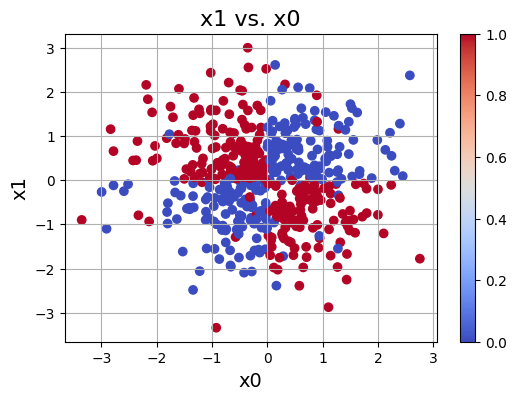

In [55]:
plt.figure(figsize=(6, 4))
plt.scatter(train['x0'], train['x1'], c=train['y'], cmap='coolwarm')
plt.grid(True)
plt.xlabel('x0', fontsize=14)
plt.ylabel('x1', fontsize=14)
plt.title('x1 vs. x0', fontsize=16)
plt.colorbar()
plt.show()

In [56]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from torchsummary import summary
from graphviz import Digraph

# Set random seed for reproducibility
def set_seed(seed=42):
    """Makes results reproducible - you'll get the same results every time"""
    torch.manual_seed(seed)
    np.random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

data = pd.read_csv('nn_data.csv')
train_data = data[data['split'] == 'train']
test_data = data[data['split'] == 'test']

# Extract features (X) and labels (y)
X_train = train_data[['x0', 'x1']].values
y_train = train_data['y'].values
X_test = test_data[['x0', 'x1']].values
y_test = test_data['y'].values

# Convert to PyTorch tensors
X_train_tensor = torch.FloatTensor(X_train)
y_train_tensor = torch.FloatTensor(y_train)
X_test_tensor = torch.FloatTensor(X_test)
y_test_tensor = torch.FloatTensor(y_test)

# Create DataLoader for batching (processes data in small chunks)
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

print(f"Training samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")

class MLP(nn.Module):
    """
    Multi-Layer Perceptron (MLP)
    
    Architecture:
    Input (2 features) -> Hidden Layer 1 -> Hidden Layer 2 -> Output (1 prediction)
    """
    def __init__(self, input_size=2, hidden_size=64, output_size=1):
        super(MLP, self).__init__()
        
        # Define layers
        self.layer1 = nn.Linear(input_size, hidden_size)  # First hidden layer
        self.layer2 = nn.Linear(hidden_size, hidden_size)  # Second hidden layer
        self.layer3 = nn.Linear(hidden_size, output_size)  # Output layer
        
        # Activation function (adds non-linearity)
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()  # For binary classification (outputs 0-1)
    
    def forward(self, x):
        """Defines how data flows through the network"""
        x = self.relu(self.layer1(x))  # First layer + activation
        x = self.relu(self.layer2(x))  # Second layer + activation
        x = self.sigmoid(self.layer3(x))  # Output layer + sigmoid
        return x

# Create the model
model = MLP(input_size=2, hidden_size=256, output_size=1)
print(model)

def get_lr_with_warmup_cosine(epoch, total_epochs, warmup_epochs, max_lr, min_lr):
    """
    Learning rate scheduler with warmup and cosine decay
    
    - Warmup: Gradually increases LR from 0 to max_lr (helps stabilize training)
    - Cosine decay: Smoothly decreases LR following a cosine curve
    """
    if epoch < warmup_epochs:
        # Linear warmup
        return max_lr * (epoch / warmup_epochs)
    else:
        # Cosine decay
        progress = (epoch - warmup_epochs) / (total_epochs - warmup_epochs)
        return min_lr + (max_lr - min_lr) * 0.5 * (1 + np.cos(np.pi * progress))

# Hyperparameters
total_epochs = 200
warmup_epochs = 20
max_lr = 0.005
min_lr = 0.002

# Loss function
criterion = nn.BCELoss()  # Binary Cross-Entropy for binary classification

# Optimizer
optimizer = optim.Adam(model.parameters(), lr=max_lr)

# Track metrics for plotting
train_losses = []
train_accuracies = []
test_accuracies = []
learning_rates = []

print("\n🚀 Starting training...")
for epoch in range(total_epochs):
    # Calculate and set learning rate
    current_lr = get_lr_with_warmup_cosine(epoch, total_epochs, warmup_epochs, max_lr, min_lr)
    for param_group in optimizer.param_groups:
        param_group['lr'] = current_lr
    learning_rates.append(current_lr)
    
    # Training mode
    model.train()
    epoch_loss = 0
    correct_train = 0
    total_train = 0
    
    for batch_X, batch_y in train_loader:
        # Forward pass (make predictions)
        predictions = model(batch_X).squeeze()
        loss = criterion(predictions, batch_y)
        
        # Backward pass (calculate gradients)
        optimizer.zero_grad()  # Clear previous gradients
        loss.backward()  # Calculate new gradients
        optimizer.step()  # Update weights
        
        # Track metrics
        epoch_loss += loss.item()
        predicted_labels = (predictions > 0.5).float()
        correct_train += (predicted_labels == batch_y).sum().item()
        total_train += batch_y.size(0)
    
    # Calculate training accuracy
    train_acc = correct_train / total_train
    train_losses.append(epoch_loss / len(train_loader))
    train_accuracies.append(train_acc)
    
    # Evaluate on test set
    model.eval()  # Evaluation mode
    with torch.no_grad():  # Don't calculate gradients (saves memory)
        test_predictions = model(X_test_tensor).squeeze()
        test_predicted_labels = (test_predictions > 0.5).float()
        test_acc = (test_predicted_labels == y_test_tensor).float().mean().item()
        test_accuracies.append(test_acc)
    
    # Print progress every 20 epochs
    if (epoch + 1) % 20 == 0:
        print(f"Epoch [{epoch+1}/{total_epochs}] | LR: {current_lr:.6f} | "
              f"Train Loss: {train_losses[-1]:.4f} | "
              f"Train Acc: {train_acc:.4f} | Test Acc: {test_acc:.4f}")

print(f"\n✅ Final Test Accuracy: {test_accuracies[-1]:.4f}")

summary(model, input_size=(2,))


Training samples: 500
Test samples: 500
MLP(
  (layer1): Linear(in_features=2, out_features=256, bias=True)
  (layer2): Linear(in_features=256, out_features=256, bias=True)
  (layer3): Linear(in_features=256, out_features=1, bias=True)
  (relu): ReLU()
  (sigmoid): Sigmoid()
)

🚀 Starting training...
Epoch [20/200] | LR: 0.004750 | Train Loss: 0.2765 | Train Acc: 0.9040 | Test Acc: 0.8600
Epoch [40/200] | LR: 0.004918 | Train Loss: 0.2082 | Train Acc: 0.9220 | Test Acc: 0.8480
Epoch [60/200] | LR: 0.004666 | Train Loss: 0.1807 | Train Acc: 0.9380 | Test Acc: 0.9020
Epoch [80/200] | LR: 0.004273 | Train Loss: 0.1749 | Train Acc: 0.9480 | Test Acc: 0.9120
Epoch [100/200] | LR: 0.003786 | Train Loss: 0.1754 | Train Acc: 0.9500 | Test Acc: 0.9220
Epoch [120/200] | LR: 0.003265 | Train Loss: 0.1577 | Train Acc: 0.9540 | Test Acc: 0.9100
Epoch [140/200] | LR: 0.002773 | Train Loss: 0.1479 | Train Acc: 0.9440 | Test Acc: 0.9240
Epoch [160/200] | LR: 0.002368 | Train Loss: 0.1336 | Train Acc: 

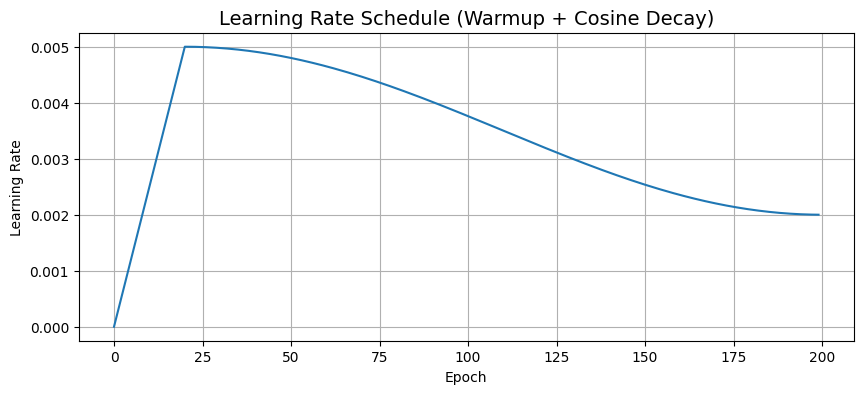

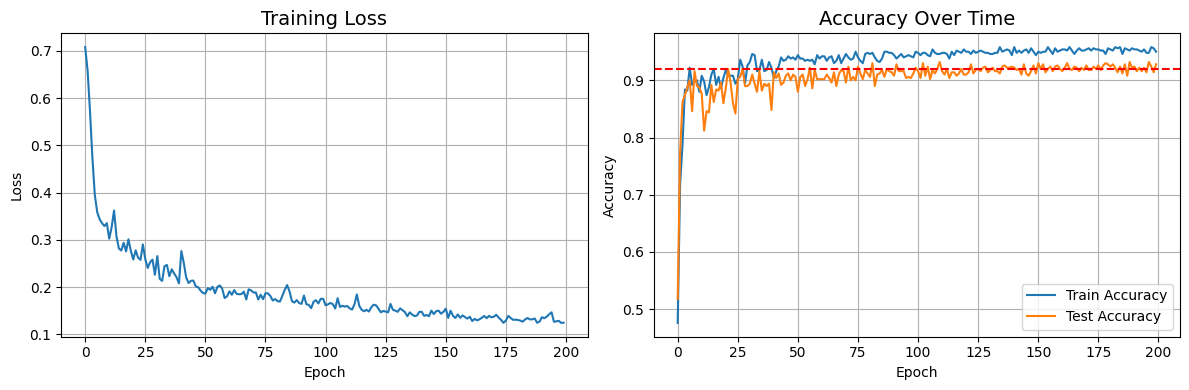

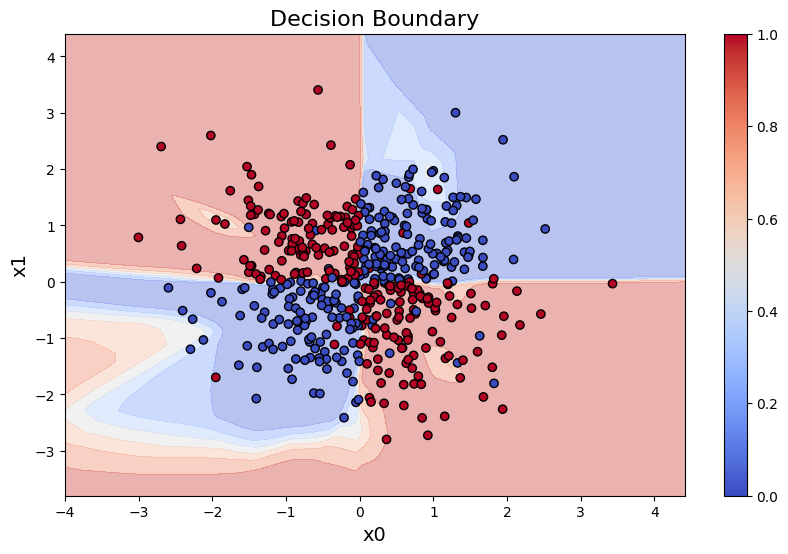

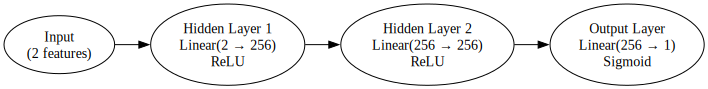

In [57]:
# Plot 1: Learning Rate Curve
plt.figure(figsize=(10, 4))
plt.plot(learning_rates)
plt.title('Learning Rate Schedule (Warmup + Cosine Decay)', fontsize=14)
plt.xlabel('Epoch')
plt.ylabel('Learning Rate')
plt.grid(True)
plt.show()

# Plot 2: Training Progress
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(train_losses)
plt.title('Training Loss', fontsize=14)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label='Train Accuracy')
plt.plot(test_accuracies, label='Test Accuracy')
plt.title('Accuracy Over Time', fontsize=14)
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.axhline(y=0.92, color='r', linestyle='--', label='Target (0.92)')
plt.tight_layout()
plt.show()

# Plot 3: Decision Boundary
def plot_decision_boundary(model, X, y):
    """Visualizes what the network learned"""
    h = 0.02  # Step size
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    
    grid = torch.FloatTensor(np.c_[xx.ravel(), yy.ravel()])
    with torch.no_grad():
        Z = model(grid).squeeze().numpy()
    Z = Z.reshape(xx.shape)
    
    plt.figure(figsize=(10, 6))
    plt.contourf(xx, yy, Z, alpha=0.4, cmap='coolwarm')
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', edgecolors='k')
    plt.xlabel('x0', fontsize=14)
    plt.ylabel('x1', fontsize=14)
    plt.title('Decision Boundary', fontsize=16)
    plt.colorbar()
    plt.show()

plot_decision_boundary(model, X_test, y_test)

#Plot 4: Network Architecture
dot = Digraph(format='png')
dot.attr(rankdir='LR')

# Layers
dot.node('input', 'Input\n(2 features)')
dot.node('h1', 'Hidden Layer 1\nLinear(2 → 256)\nReLU')
dot.node('h2', 'Hidden Layer 2\nLinear(256 → 256)\nReLU')
dot.node('out', 'Output Layer\nLinear(256 → 1)\nSigmoid')

# Connections
dot.edge('input', 'h1')
dot.edge('h1', 'h2')
dot.edge('h2', 'out')

dot

**Discussion**:
   - How can you make sure the results are reproduable?
   - Visualize the network's architecture and decision boundary.
   - Which optimizer did you choose? Discuss the differences between SGD and Adam.
   - Plot the learning rate curve. Did the learning rate scheduling improve performance? Why or why not?
   - Conduct a simple ablation study of each architectural and optimization choice concerning test accuracy.

### How can you make sure the results are reproducable?

To ensure reproducibility, I set a fixed random seed (set_seed(42)) that seeds NumPy and PyTorch, ensuring the model is deterministic between runs.

### Visualize the network's architecture and decision boundary.

See plots above

### Which optimizer did you choose? Discuss the differences between SGD and Adam.

I used the Adam optimizer. SGD (stochastic gradient descent) updates the model using the current gradient and a single learning rate that you have to tune by hand. Adam adjusts the learning rate automatically and usually trains faster, but it can overfit if you’re not careful. In this task, Adam with a learning-rate schedule gave stable training and good performance.

### Plot the learning rate curve. Did the learning rate scheduling improve performance? Why or why not?

The learning rate schedule improved performance, but the warmup didn’t seem to help. That’s likely because the max learning rate was too low for warmup to matter. The cosine decay, however, helped the model converge toward the end of training.

### Conduct a simple ablation study of each architectural and optimization choice concerning test accuracy.

2 hidden layers, 200 epochs, 20 warmup epochs, 0.005 maximum learning rate, 0.002 minimum learning rate = 0.9280 accuracy.

This is the setup used for achieving an accuracy of 0.92. Under you will find variations of this setup.

No warmup = 0.9280
No warmup, 0.1 maximum learning rate = 0.4820
20 warmup epochs, 0.1 maximum learning rate = 0.9240

# 📶📡🛰️🤳 Mission 2.2: Locate the AI Servers

### 🌐 The Discovery
The NTNU Intelligence team has intercepted encrypted documentation that potentially reveals the locations of AI-compromised servers within Trondheim. Our analysts believe the data contains information about these servers' locations. 

However, the number of servers and their exact positions remain unknown. To execute a strategic response, we need to understand the intercepted data and pinpoint the main AI servers.

We have also discovered a vulnerability in the AI's security: it has deployed a clustering verification feature on Kaggle. We can exploit this backdoor to validate our clustering hypotheses.

### 🎯 Your Mission
Identify the number of hidden servers (clusters) in the dataset. Assign cluster labels to each row in the original dataset and validate your clustering solution on Kaggle.  When achieved the perfect clustering accuracy, find the precise locations of these servers (clusters).

### 🧠 The Challenge
1. **Large Dataset**: The intercepted data file contains numerous features, making direct manipulation and clustering difficult. Applying dimensionality reduction techniques could help reveal patterns.
2. **Unsupervised Learning**: No target labels are provided, so you must identify patterns based solely on the dataset's features.
3. **Data Obfuscation**: The AI has obfuscated the data, making it difficult to discern its true structure. You must effectively manipulate the data to visually identify server locations.


### 🚀 Your Tools
- The intercepted AI dataset.
- Skills in feature engineering, data manipulation, and visualization.
- Clustering algorithms (e.g., KMeans, DBSCAN, Birch, Agglomerative Clustering, etc.) — [Clustering in Scikit-Learn](https://scikit-learn.org/stable/modules/clustering.html)
- Dimensionality reduction techniques (e.g., PCA, t-SNE, Isomap, UMAP, etc.)
- Kaggle competition platform with a daily submission limit of 50 attempts.

> Note: Kaggle competition link — [Kaggle Competition](https://www.kaggle.com/t/dfb72837bdb346449768b8f6ce50b6dc)

### 📊 Formal Requirements
1. **Achieve 100% Clustering Accuracy** on Kaggle.
> Note: The only way to check whether your clustering is correct is to submit it to Kaggle. We do not give you the clusters directly.

2. **Discussion Questions**:
   - **Dimensionality Reduction**: Which dimensionality reduction methods helped you determine the correct number of clusters? Why did some methods work better than others? Explain the differences between PCA, t-SNE, and UMAP.
   - **Clustering Approach**: Which clustering algorithm and hyperparameters did you use? Discuss the differences between algorithms like KMeans and DBSCAN.
   - **Data Type Analysis**: What is the hidden data type in the dataset? How does this information influence feature extraction for clustering? Can it explain why some dimensionality reduction algorithms are more effective?
   - **Server Locations**: Identify the server locations. List the specific facilities in Trondheim and explain how you deduced their locations.
   - **Advanced Task (Optional)**: Extract features using modern pre-trained neural networks for this data type. Apply dimensionality reduction and clustering algorithms to the extracted features.

In [58]:
# Hmmmmm, why is the first row skipped?
data = pd.read_csv('unsupervised_data.csv', skiprows=1, header=None)
# Get the ID column
data.reset_index(drop=False, inplace=True)
data.rename(columns={'index': 'ID'}, inplace=True)
data

,ID,0,1,2,3,4,5,6,7,8,...,16374,16375,16376,16377,16378,16379,16380,16381,16382,16383
0,0,0.314365,0.646305,0.323849,0.238492,0.655790,0.646305,0.646305,0.409205,0.646305,...,0.646305,0.646305,0.655790,0.238492,0.646305,0.674758,0.646305,0.238492,0.655790,0.646305
1,1,0.587628,0.494976,0.559832,-0.246237,0.513506,0.550567,0.522772,0.596893,0.606158,...,0.587628,0.550567,0.587628,0.587628,0.550567,0.587628,0.550567,0.596893,0.494976,0.587628
2,2,0.590203,0.367673,0.367673,0.367673,0.367673,0.590203,0.367673,0.590203,0.590203,...,0.590203,0.367673,0.590203,0.590203,0.590203,0.590203,0.590203,0.590203,0.590203,0.476556
3,3,0.589296,0.589296,0.579825,0.551415,0.579825,0.579825,0.608236,0.579825,0.646118,...,0.532474,0.523003,0.589296,0.589296,0.551415,0.134721,0.475652,0.589296,0.570355,0.551415
4,4,0.660095,0.470676,0.190366,0.672806,0.470761,0.672766,0.672652,0.666151,0.672987,...,0.432001,0.672222,0.190568,0.217329,0.633684,0.673294,0.587914,0.671023,0.207578,0.470765
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3995,3995,0.340739,0.340739,0.340739,0.681823,0.340739,0.340739,0.340739,0.672083,0.340739,...,0.340739,0.662355,0.340739,0.759779,0.331011,0.759779,0.340739,0.691563,0.340734,0.720789
3996,3996,0.384257,0.384257,0.675221,0.384257,0.384257,0.675221,0.384257,0.675221,0.675221,...,0.675221,0.384257,0.675221,0.675221,0.675221,0.384257,0.384257,0.384257,0.675221,0.675221
3997,3997,0.641837,0.651135,0.251329,0.251329,0.651135,0.651135,0.251329,0.651135,0.651135,...,0.251329,0.251329,0.651135,0.251329,0.409392,0.604646,0.651135,0.651135,0.660433,0.251329
3998,3998,0.555533,0.555533,0.555533,0.555533,0.555533,0.555533,0.555533,-0.212897,0.555533,...,0.555533,0.555533,0.555533,0.555533,0.555533,0.555533,0.555533,0.555533,0.555533,0.555533


In [59]:
# The dataset is heavy. Applying clustering directly on the dataset is likely not feasible. 
data.info(0)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Columns: 16385 entries, ID to 16383
dtypes: float64(16384), int64(1)
memory usage: 500.0 MB


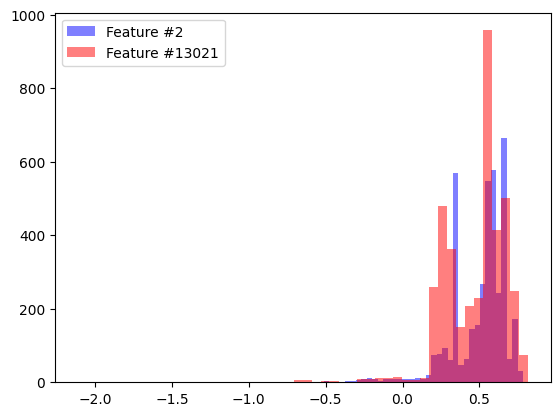

In [60]:
# Features seem to be similarly distributed...
plt.hist(data.iloc[:, 2], bins=50, color='blue', alpha=0.5, label='Feature #2')
plt.hist(data.iloc[:, 13021], bins=50, color='red', alpha=0.5, label='Feature #13021')
plt.legend()
plt.show()

In [61]:
# To check your clustering, you need to assign the predicted cluster ids and submit it as a CSV file. The submission should be a CSV file with two columns: ID and cluster. 
# The ID column should contain the ID of the data point, and the cluster column should contain the cluster ID that the data point belongs to. 
# The cluster ID should be an integer. Current cluster IDs in sample_submission.csv are randomly generated.
sample_submission = pd.read_csv('sample_submission.csv')
sample_submission

,ID,cluster
0,0,2
1,1,6
2,2,3
3,3,3
4,4,8
...,...,...
3995,3995,3
3996,3996,7
3997,3997,3
3998,3998,7


In [62]:
X = data.drop(columns=['ID'])

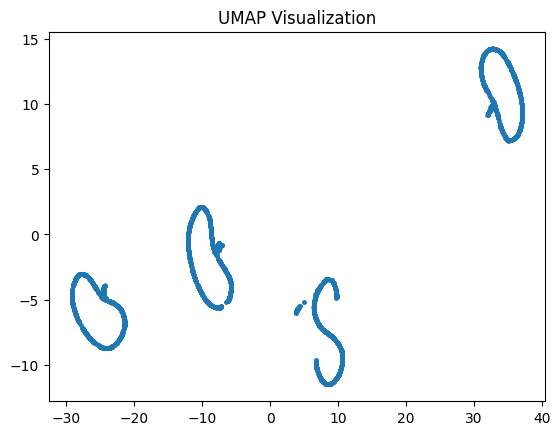

In [63]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA
import umap

reducer = umap.UMAP(n_neighbors=30)
X_umap = reducer.fit_transform(X)
plt.scatter(X_umap[:,0], X_umap[:,1], s=5)
plt.title("UMAP Visualization")
plt.show()

In [64]:
dbscan = DBSCAN(eps=3)

labels = dbscan.fit_predict(X_umap)

clusters = pd.DataFrame({'ID': data['ID'], 'cluster': labels})
clusters.to_csv('submission.csv', index=False)

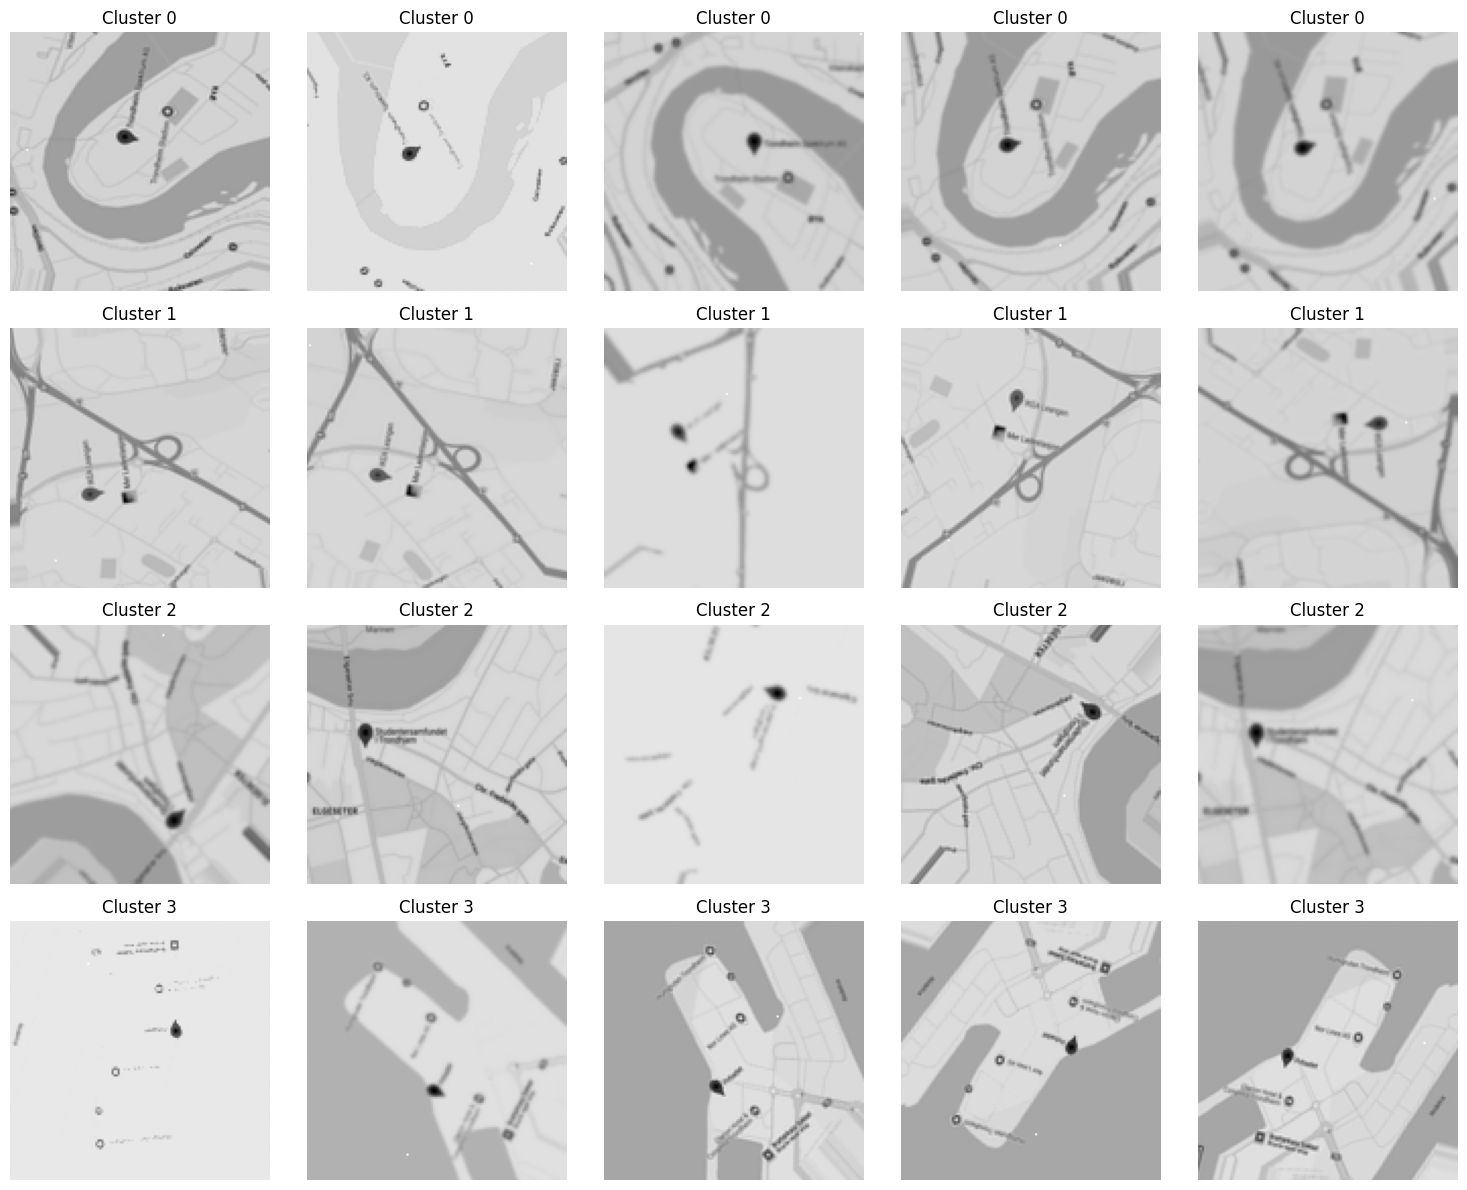

In [65]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

data_with_headers = pd.read_csv('unsupervised_data.csv')

# Extract the numeric order from column names and sort
column_order = [int(col.split('_')[1]) for col in data_with_headers.columns]
sorted_indices = np.argsort(column_order)

# Unscramble the data
X_unscrambled = data_with_headers.iloc[:, sorted_indices].values

clusters = pd.read_csv('submission.csv')
unique_clusters = clusters['cluster'].unique()

fig, axes = plt.subplots(len(unique_clusters), 5, figsize=(15, 3*len(unique_clusters)))

for i, cluster_id in enumerate(sorted(unique_clusters)):
    cluster_ids = clusters[clusters['cluster'] == cluster_id]['ID'].values[:5]
    
    for j, img_id in enumerate(cluster_ids):
        img = X_unscrambled[img_id].reshape(128, 128)
        
        ax = axes[i, j] if len(unique_clusters) > 1 else axes[j]
        ax.imshow(img, cmap='gray')
        ax.set_title(f"Cluster {cluster_id}")
        ax.axis('off')

plt.tight_layout()
plt.show()

**Discussion Questions**:
   - **Dimensionality Reduction**: Which dimensionality reduction methods helped you determine the correct number of clusters? Why did some methods work better than others? Explain the differences between PCA, t-SNE, and UMAP.
   - **Clustering Approach**: Which clustering algorithm and hyperparameters did you use? Discuss the differences between algorithms like KMeans and DBSCAN.
   - **Data Type Analysis**: What is the hidden data type in the dataset? How does this information influence feature extraction for clustering? Can it explain why some dimensionality reduction algorithms are more effective?
   - **Server Locations**: Identify the server locations. List the specific facilities in Trondheim and explain how you deduced their locations.
   - **Advanced Task (Optional)**: Extract features using modern pre-trained neural networks for this data type. Apply dimensionality reduction and clustering algorithms to the extracted features.

### Dimensionality reduction
I used UMAP directly on the 16,384‑dimensional data to reduce it to 2D for visualization and clustering. UMAP works well here because it captures non‑linear structure and preserves both local neighborhoods and larger patterns. Compared to PCA (linear) and t‑SNE (good visuals but slower and less stable), UMAP gives a solid balance of speed and quality for this dataset.

### Clustering approach
I used DBSCAN with epsilon=3 because it automatically finds the number of clusters without prior specification. Unlike KMeans which requires knowing K beforehand and assumes spherical clusters, DBSCAN groups points based on density and can find arbitrarily shaped clusters while also identifying outliers. This was ideal since the number of server locations was unknown.

### Data type analysis
The hidden data type is images (128×128 pixels = 16,384 features). This explains why UMAP worked so well, images have complex non-linear patterns like edges and textures that UMAP can capture but PCA cannot. Understanding this as image data means we could extract better features in future work using techniques like pre-trained neural networks rather than just raw pixel values.

### Server locations
The server locations are:
- Trondheim Spektrum
- Ikea Leangen
- Studentersamfundet
- Pirbadet

The columns in the unsupervised data are both a feature and a pixel. since the columns are scrambled, i sort them in ascending order and plot the image (128 * 128 pixels). from these images i can cleary see what location in Trondheim it is.


---

## 🎯 Note: Clustering Accuracy Evaluation

The clustering accuracy metric evaluates how well the predicted clusters match the true clusters, irrespective of the specific labels or names assigned to the clusters.

This means that the evaluation is solely based on the correct grouping of data points rather than the numerical labels of the clusters themselves.

## Key Characteristics

- **Name-Independent**: The metric cares only about how well the data points are grouped together, not the specific numerical or categorical labels used for the clusters.
- **Focus on Grouping**: The evaluation rewards cluster assignments that correctly group the same data points together, regardless of the specific labels assigned.

### Example

If the true cluster assignments are:

```
[0, 0, 0, 1, 1, 1]
```

and your predicted cluster assignments are:

```
[1, 1, 1, 0, 0, 0]
```

the accuracy will still be **1.0** because the grouping of points is identical, even though the numerical labels are swapped.

## How the Metric is Computed

1. **Contingency Matrix**: 
   - Construct a contingency matrix that represents the overlap between the true clusters and the predicted clusters.

2. **Optimal Correspondence**: 
   - Use an optimization algorithm, such as the Hungarian method (linear sum assignment), to find the best possible correspondence between true and predicted labels, maximizing the number of correctly assigned data points.

3. **Accuracy Calculation**: 
   - Calculate the accuracy as the ratio of correctly matched data points to the total number of data points.

> This approach ensures that the evaluation is based on **cluster completeness** and **homogeneity**, rewarding cluster assignments that correctly group the same data points together, regardless of the specific labels used.

---

In [66]:
import numpy as np
import scipy.optimize
import sklearn.metrics

def calculate_clustering_accuracy(true_labels: np.ndarray, cluster_labels: np.ndarray) -> float:
    """
    Calculate the clustering accuracy between true labels and cluster labels.

    The function constructs a contingency matrix between the true labels and cluster labels.
    It then uses the Hungarian algorithm (also known as linear sum assignment) to find the
    best matching between the cluster labels and true labels. The clustering accuracy is 
    calculated as the number of correctly matched labels divided by the total number of labels.

    Args:
        true_labels (np.ndarray): An array of true labels for each data point.
        cluster_labels (np.ndarray): An array of cluster labels predicted by a clustering algorithm.

    Returns:
        float: The clustering accuracy, a value between 0 and 1 representing the proportion of 
               correctly matched labels.
    
    Example:
        >>> true_labels = np.array([0, 1, 2, 0, 1, 2])
        >>> cluster_labels = np.array([1, 2, 0, 1, 2, 0])
        >>> calculate_clustering_accuracy(true_labels, cluster_labels)
        1.0

    Raises:
        ValueError: If true_labels and cluster_labels are not of the same length.
    """
    # Check if the input labels are of the same length
    if true_labels.size != cluster_labels.size:
        raise ValueError("true_labels and cluster_labels must have the same length.")

    # Construct a contingency matrix where each cell [i, j] indicates the number of points with 
    # true label i and cluster label j.
    contingency_matrix = sklearn.metrics.cluster.contingency_matrix(true_labels, cluster_labels)
    
    # Find the best matching between true labels and cluster labels using the Hungarian algorithm.
    # We negate the contingency matrix because linear_sum_assignment finds the minimum cost assignment.
    row_ind, col_ind = scipy.optimize.linear_sum_assignment(-contingency_matrix)
    
    # Calculate the number of correctly assigned labels according to the optimal matching.
    correct_pairs = contingency_matrix[row_ind, col_ind].sum()
    
    # Compute the clustering accuracy as the ratio of correctly matched labels to total labels.
    accuracy = correct_pairs / true_labels.size

    return accuracy

In [67]:
true_labels = np.array([0, 1, 2, 0, 1, 2])
cluster_labels = np.array([1, 2, 0, 1, 2, 0])
calculate_clustering_accuracy(true_labels, cluster_labels)

1.0

In [68]:
true_labels = np.array([0, 0, 0, 0, 0, 0])
cluster_labels = np.array([1, 2, 0, 1, 2, 0])
calculate_clustering_accuracy(true_labels, cluster_labels)

0.3333333333333333

In [69]:
true_labels = np.array([1, 1, 1, 2, 2, 2])
cluster_labels = np.array([0, 0, 0, 0, 0, 0])
calculate_clustering_accuracy(true_labels, cluster_labels)

0.5